# 直接估计 $\sigma^2/\theta$ 与 $\sigma$（单轨迹，基于 SPINN）

前两个 notebook 一直在估计均值回复速率 $\theta_t$，但它需要从很弱的漂移信号中读取，是最难的量。如果真正关心的是

$$
R_t \equiv \frac{\sigma_t^2}{\theta_t}\qquad\text{和}\qquad \sigma_t ,
$$

那么可以换一条路：**完全不经过漂移**。对 OU 过程

$$
\mathrm{d}X_t = \theta(\mu - X_t)\,\mathrm{d}t + \sigma\,\mathrm{d}W_t ,
$$

有两个只涉及方差的恒等式：

$$
\underbrace{\mathrm{Var}_{\text{stat}}(X)}_{\text{位置的平稳方差}} = \frac{\sigma^2}{2\theta} = \frac{R}{2},
\qquad
\underbrace{\mathrm{Var}[X_{n+1}\mid X_n]}_{\text{单步方差}} = \frac{R}{2}\left(1-e^{-2\theta\Delta}\right)\approx \sigma^2\Delta .
$$

- $R=\sigma^2/\theta$ 就是位置平稳方差的两倍，也是 MSD 曲线的平台值。在粒子追踪/光镊中，这就是**均分定理**：$\sigma^2/\theta = 2k_BT/\kappa$，$\kappa$ 为势阱刚度。
- $\sigma$ 来自单步方差，正是 SPINN 在单轨迹上最可靠的输出。
- 两者都只需要**局部方差**：减去局部均值就自动去掉了每条轨迹的 $\mu_i$，不需要知道 $\mu_i$，也不受漂移估计偏差的影响。

需要注意的前提：用局部方差估计平稳方差，要求参数的变化比松弛时间 $1/\theta$ 慢（准平稳）。参数变化很快时，位置的实际方差 $V_t$ 会滞后于瞬时值 $R_t/2$，它满足

$$
\frac{\mathrm dV_t}{\mathrm dt} = -2\theta_t V_t + \sigma_t^2 .
$$

本 notebook 以瞬时的 $R_t=\sigma_t^2/\theta_t$ 为目标，同时画出 $2V_t$ 作为参考。

> **运行前提**：与 `SPINN_OU_theta_explore.ipynb` 相同，需要先运行 `SPINN_OU_demo.ipynb` 得到训练好的模型。本 notebook 使用与 `SPINN_OU_theta_explore.ipynb` 相同的 32 条独立测试轨迹（每个情景），在 4 核 CPU 上约 3 分钟跑完。

## 0. 环境与配置

网络配置必须与 `SPINN_OU_demo.ipynb` 训练时一致（`QUICK = True` 的设置）。

In [1]:
import os, sys, time, types, argparse, warnings, itertools
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath('.')
while not os.path.exists(os.path.join(REPO_ROOT, 'TrainJumpSDEsTransform.py')):
    parent = os.path.dirname(REPO_ROOT)
    if parent == REPO_ROOT:
        raise FileNotFoundError('请把 notebook 放在 SPINN 仓库内运行')
    REPO_ROOT = parent
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

try:
    import pkg_resources  # noqa: F401
except ImportError:  # 新版 setuptools 已移除 pkg_resources，仓库的 robust_loss_pytorch 需要它
    _shim = types.ModuleType('pkg_resources')
    def _resource_stream(package, resource):
        return open(os.path.join(os.path.dirname(sys.modules[package].__file__), resource), 'rb')
    _shim.resource_stream = _resource_stream
    sys.modules['pkg_resources'] = _shim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.ndimage import uniform_filter1d

from model.JumpSDEsTrans import JumpSDEsTransformer
from TrainJumpSDEsTransform import (DatasetTracks, generate_dataset_torch, train_sigma, train_velocity,
                                    transform, load)
from utils.csv2npy import v_normalize_batch_encoder

torch.set_num_threads(os.cpu_count())
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

C_TRUE = '#3a3a38'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 1.6,
                     'font.size': 9, 'legend.frameon': False, 'axes.unicode_minus': False})

# 与 SPINN_OU_demo.ipynb（QUICK = True）相同的网络配置
cfg = argparse.Namespace(
    epochs=12, epochs_VDt=6, batch_size=20, lr=1e-3, seed=0, clip_grad=5.0, scale=0.375, warmup_steps=100,
    RESUME=False, default_enc_nn=((64, 'gelu'), (64, 'gelu')), hidden_size=64, layers=2, h_dim=32,
    d_model=64, n_heads=4, enc_layers=2, dropout=0.25, is_var_head=True, in_dim=2, out_dim=2,
    pred_length=50, encoder_length=50, beta_ac=0.5, beta_weight=0.5, beta_observe=0.0, beta_conti=0.0,
    noise_adding=0.0, sample_rates=1.0, sample_nums=0,
    dload='./model_dir/ou_demo', save_name='ou-demo', model_name='ou-demo.pth', device=DEVICE,
)
for f in ['ou-demo.pth', 'ou-demo-var.pth', 'ou-demo-vel.pth']:
    if not os.path.exists(os.path.join(cfg.dload, f)):
        raise FileNotFoundError(f'找不到 {cfg.dload}/{f}，请先完整运行 SPINN_OU_demo.ipynb')

model = JumpSDEsTransformer(in_dim=cfg.in_dim, out_dim=cfg.in_dim, encoding_len=cfg.encoder_length,
                            h_dim=cfg.h_dim, default_enc_nn=cfg.default_enc_nn, hidden_dim=cfg.hidden_size,
                            layers=cfg.layers, d_model=cfg.d_model, n_head=cfg.n_heads, layers_enc=cfg.enc_layers,
                            dropout=cfg.dropout, device=cfg.device).to(cfg.device)
load(model, cfg.dload, cfg.model_name)
L_ENC, L_PRED = cfg.encoder_length, cfg.pred_length
WIN = L_ENC + L_PRED
print('模型已加载 | device:', DEVICE)

模型已加载 | device: cpu


## 1. 独立测试数据：$\mu_i$ 各不相同的时变 OU 轨迹

模拟参数与 `SPINN_OU_demo.ipynb` 相同（$\Delta=0.02$、每条轨迹 1000 帧、6 种 $\theta_t/\sigma_t$ 组合），使用精确离散化：

$$
X_{n+1} = \mu_i + (X_n-\mu_i)\,e^{-\theta_n\Delta} + \sigma_n\sqrt{\tfrac{1-e^{-2\theta_n\Delta}}{2\theta_n}}\;\xi_n .
$$

这里用**新的随机种子**生成每个情景 32 条轨迹。它们既没有参与训练，也没有在 `SPINN_OU_demo.ipynb` 里被用来挑选方法。每条轨迹的平衡位置 $\mu_i = (2,-1) + \delta_i$，$\delta_i\sim\mathcal N(0, 1^2)$。

In [2]:
DT, T_LEN, N_EVAL = 0.02, 1000, 32
MU0 = np.array([2.0, -1.0])
t_grid = np.arange(T_LEN) * DT
T_END = t_grid[-1] + DT
square_wave = lambda t, period: (np.floor(t / (period / 2)) % 2).astype(float)

SCENARIOS = {
    'A 常数基准':        dict(en='A: constant θ, σ',         theta=lambda t: 4.0 + 0 * t, sigma=lambda t: 1.0 + 0 * t),
    'B σ 阶跃':          dict(en='B: σ step',                theta=lambda t: 4.0 + 0 * t, sigma=lambda t: np.where(t < T_END / 2, 0.6, 1.5)),
    'C σ 正弦':          dict(en='C: σ sine',                theta=lambda t: 4.0 + 0 * t, sigma=lambda t: 1.0 + 0.5 * np.sin(2 * np.pi * t / 10)),
    'D θ 线性增加':      dict(en='D: θ ramp',                theta=lambda t: 1.0 + 9.0 * t / T_END, sigma=lambda t: 1.0 + 0 * t),
    'E θ 正弦 + σ 线性': dict(en='E: θ sine + σ ramp',       theta=lambda t: 5.0 + 3.0 * np.sin(2 * np.pi * t / 8), sigma=lambda t: 0.5 + 1.0 * t / T_END),
    'F θ/σ 反相切换':     dict(en='F: θ/σ anti-phase switch', theta=lambda t: 2.0 + 6.0 * square_wave(t, 10), sigma=lambda t: 1.4 - 0.7 * square_wave(t, 10)),
}
names = list(SCENARIOS)
EN = {k: v['en'] for k, v in SCENARIOS.items()}

def simulate_ou(theta_fn, sigma_fn, n_tracks, rng, mu_spread=1.0):
    th, sg = theta_fn(t_grid), sigma_fn(t_grid)
    a = np.exp(-th * DT)
    sd = sg * np.sqrt((1 - a ** 2) / (2 * th))
    mu = MU0 + mu_spread * rng.standard_normal((n_tracks, 1, 2))          # 每条轨迹自己的 μ_i
    X = np.empty((n_tracks, T_LEN, 2))
    X[:, 0] = mu[:, 0] + sg[0] / np.sqrt(2 * th[0]) * rng.standard_normal((n_tracks, 2))
    for n in range(T_LEN - 1):
        X[:, n + 1] = mu[:, 0] + (X[:, n] - mu[:, 0]) * a[n] + sd[n] * rng.standard_normal((n_tracks, 2))
    return dict(X=X, mu=mu, theta=th, sigma=sg, sigma_eff=sd / np.sqrt(DT))

rng = np.random.default_rng(2025)
DATA = {name: simulate_ou(sc['theta'], sc['sigma'], N_EVAL, rng) for name, sc in SCENARIOS.items()}
print({k: v['X'].shape for k, v in DATA.items()})

{'A 常数基准': (32, 1000, 2), 'B σ 阶跃': (32, 1000, 2), 'C σ 正弦': (32, 1000, 2), 'D θ 线性增加': (32, 1000, 2), 'E θ 正弦 + σ 线性': (32, 1000, 2), 'F θ/σ 反相切换': (32, 1000, 2)}


## 2. SPINN 推断

与 `SPINN_OU_demo.ipynb` 第 3、6 节完全相同：先切成 regular + head 片段并归一化，再依次调用仓库的 `transform`、`train_sigma(is_train=False)`、`train_velocity(is_train=False)`，最后反归一化并拼回整条轨迹。得到每条轨迹、每一帧的漂移 $v^{(1)}$ 和扩散 $s^{(1)}$。

In [3]:
def segment(arr, is_head=False):
    if is_head:
        arr = np.concatenate([np.repeat(arr[:, :1], L_PRED, axis=1), arr[:, :-L_PRED]], axis=1)
    starts = np.arange(0, arr.shape[1] - WIN + 1, WIN)
    return np.concatenate([arr[:, s:s + WIN][:, None] for s in starts], axis=1).reshape(-1, WIN, *arr.shape[2:])

def build_segments(X):
    N = X.shape[0]
    frame = np.broadcast_to(np.arange(T_LEN), (N, T_LEN))
    track = np.broadcast_to(np.arange(N)[:, None], (N, T_LEN))
    out = {}
    for kind, head in [('regular', False), ('head', True)]:
        seg_norm, s = v_normalize_batch_encoder(segment(X, head), encoder_len=L_ENC)
        out[kind] = dict(x=seg_norm.astype(np.float32), norm=s, frame=segment(frame, head), track=segment(track, head))
    return out

def spinn_infer(seg_x):
    ds = DatasetTracks(seg_x, cfg, sample_rate=1.0)
    _, test_ds = generate_dataset_torch(ds, seed=cfg.seed, train_prob=1e-6)
    _, y1, _, _ = transform(test_ds, model, cfg)
    s_ds, model_s = train_sigma(test_ds, model, cfg, is_train=False)
    _, s1, _, _ = transform(s_ds, model_s, cfg)
    v_ds, model_v = train_velocity(test_ds, model, cfg, is_train=False)
    _, v1, _, _ = transform(v_ds, model_v, cfg)
    tb = lambda a: a.transpose(1, 0, 2)[:, -L_PRED:]
    return dict(v1=tb(v1), s1=tb(s1))

def infer_tracks(X):
    segs, N = build_segments(X), X.shape[0]
    full = {k: np.full((N, T_LEN, 2), np.nan) for k in ['v1', 's1']}
    for kind in ['regular', 'head']:
        seg = segs[kind]
        o = spinn_infer(seg['x'])
        s = seg['norm'].reshape(1, 1, 2)
        fr, tr = seg['frame'][:, L_ENC:], seg['track'][:, L_ENC:]
        full['v1'][tr, fr] = o['v1'] * s
        full['s1'][tr, fr] = o['s1'] * s ** 2
    return full

t0 = time.time()
RES = {name: infer_tracks(DATA[name]['X']) for name in names}
print(f'SPINN 推断完成，用时 {time.time() - t0:.0f}s')

SPINN 推断完成，用时 46s


## 3. 真值与评估指标

对每个情景计算：瞬时目标 $R_t=\sigma_t^2/\theta_t$；位置实际方差的两倍 $2V_t$（按精确离散化递推 $V_{n+1}=V_n e^{-2\theta_n\Delta}+\mathrm{Var}[X_{n+1}\mid X_n]$）；以及 $\sigma_t$。

由于 $R_t$ 在 F 情景中会跨越 16 倍（0.06 → 0.98），相对误差会被小值主导，所以主要指标用**对数误差**：

$$
\text{logMAE} = \operatorname{median}_i\ \frac1T\sum_n\left|\ln\frac{\hat R^{(i)}_n}{R_n}\right| ,
$$

例如 logMAE = 0.2 大约对应 20% 的典型误差。趋势指标为单轨迹估计与真值（取对数后）的相关系数，同样取 32 条轨迹的中位数。$\sigma$ 的指标用相对误差（MRE）和相关系数。

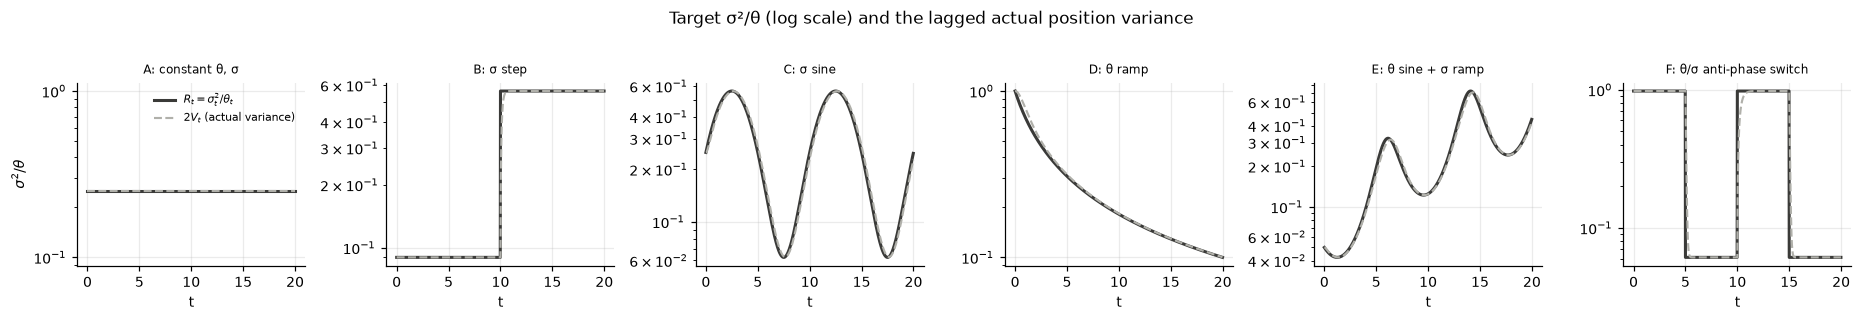

In [4]:
TRUTH = {}
for name in names:
    d = DATA[name]
    th, sg = d['theta'], d['sigma']
    a = np.exp(-th * DT)
    step_var = sg ** 2 * (1 - a ** 2) / (2 * th)
    V = np.empty_like(th); V[0] = sg[0] ** 2 / (2 * th[0])
    for n in range(T_LEN - 1):
        V[n + 1] = V[n] * a[n] ** 2 + step_var[n]
    TRUTH[name] = dict(R=sg ** 2 / th, R_trans=2 * V, sigma=sg)

def _corr_rows(a, b):
    a = a - a.mean(axis=1, keepdims=True); b = b - b.mean()
    return (a @ b) / (np.sqrt((a ** 2).sum(axis=1)) * np.sqrt((b ** 2).sum()) + 1e-12)

def score_R(est, name, sl=slice(None)):
    R = TRUTH[name]['R'][sl]; est = np.clip(est[:, sl], 1e-9, None)
    return {'logMAE': np.median(np.mean(np.abs(np.log(est / R)), axis=1)),
            'MRE': np.median(np.mean(np.abs(est - R) / R, axis=1)),
            'corr(log)': np.median(_corr_rows(np.log(est), np.log(R))) if R.std() > 1e-12 else np.nan}

def score_sigma(est, name, sl=slice(None)):
    sg = TRUTH[name]['sigma'][sl]; est = est[:, sl]
    return {'MRE': np.median(np.mean(np.abs(est - sg) / sg, axis=1)),
            'corr': np.median(_corr_rows(est, sg)) if sg.std() > 1e-12 else np.nan}

def pivot(scores, methods, key):
    df = pd.DataFrame([dict(情景=n, 方法=m, **scores[n][m]) for n in names for m in methods]) \
           .pivot(index='情景', columns='方法', values=key)[methods]
    if key in ('logMAE', 'MRE'):
        df.loc['6 个情景平均'] = df.mean()
    return df

fig, axes = plt.subplots(1, 6, figsize=(17, 2.8))
for ax, name in zip(axes, names):
    ax.plot(t_grid, TRUTH[name]['R'], color=C_TRUE, lw=2, label=r'$R_t=\sigma_t^2/\theta_t$')
    ax.plot(t_grid, TRUTH[name]['R_trans'], color='#b0b0aa', lw=1.4, ls='--', label=r'$2V_t$ (actual variance)')
    ax.set_yscale('log'); ax.set_title(EN[name], fontsize=8); ax.set_xlabel('t')
axes[0].set_ylabel(r'$\sigma^2/\theta$'); axes[0].legend(fontsize=7)
fig.suptitle('Target σ²/θ (log scale) and the lagged actual position variance', y=1.02)
fig.tight_layout(); plt.show()

## 4. 估计 $\sigma_t$

| 方法 | 做法 |
|---|---|
| `SPINN` | SPINN 扩散输出 $s^{(1)}$（单步方差），25 帧平滑，$\hat\sigma=\sqrt{s^{(1)}/\Delta}$ |
| `实现方差 (W=50)` | 经典做法：$\hat\sigma^2=\frac{1}{W\Delta}\sum(\Delta X)^2$，50 帧滑动窗口（忽略漂移） |
| `OLS 残差 (W=100)` | 滑动窗口回归 $\Delta X=c+kX$ 的残差方差 $/\Delta$ |
| `MSD 拟合 (W=200)` | 见第 5 节，由拟合得到的 $R\theta$ 换算 |

In [5]:
_roll = lambda z, W: uniform_filter1d(z, W, axis=1, mode='nearest')

def rollvar(X, W):
    """去掉局部均值后的滑动窗口方差，两维平均 -> (N,T)"""
    return (_roll(X * X, W) - _roll(X, W) ** 2).mean(axis=2) * W / (W - 1)

def rolling_ols(X, W):
    """滑动窗口 ΔX = c + kX：返回斜率 k 与残差方差 s²，两维平均 -> (N,T)"""
    dX = np.diff(X, axis=1, append=X[:, -1:])
    mx, my = _roll(X, W), _roll(dX, W)
    vxx, vxy, vyy = _roll(X * X, W) - mx ** 2, _roll(X * dX, W) - mx * my, _roll(dX * dX, W) - my ** 2
    k = vxy / vxx
    s2 = np.clip(vyy - k * vxy, 1e-12, None) * W / (W - 2)
    return k.mean(axis=2), s2.mean(axis=2)

def msd_fit(X, W=200, taus=np.arange(1, 41), stride=10):
    """滑动窗口 MSD 拟合：每维 MSD(τ) = R(1 - e^{-θτΔ})，返回 R 与 σ² = Rθ (N,T)；每 stride 帧拟合一次再插值"""
    N, T, _ = X.shape
    centers = np.arange(0, T, stride)
    R_c, S_c = np.empty((N, len(centers))), np.empty((N, len(centers)))
    for ci, c in enumerate(centers):
        b = min(T, max(0, c - W // 2) + W); a = max(0, b - W)
        seg = X[:, a:b]
        msd = np.stack([((seg[:, t:] - seg[:, :-t]) ** 2).mean(axis=(1, 2)) for t in taus], axis=1)
        for i in range(N):
            m = msd[i]
            res = lambda p: (np.exp(p[0]) * (1 - np.exp(-np.exp(p[1]) * taus * DT)) - m) / m
            p = least_squares(res, [np.log(m[-1]), np.log(max(m[0] / (m[-1] * DT), 0.1))]).x
            R_c[i, ci], S_c[i, ci] = np.exp(p[0]), np.exp(p[0] + p[1])
    t = np.arange(T)
    interp = lambda A: np.stack([np.interp(t, centers, A[i]) for i in range(N)])
    return interp(R_c), interp(S_c)

from scipy.optimize import least_squares

S_EST, R_EST = {n: {} for n in names}, {n: {} for n in names}
t0 = time.time()
for name in names:
    X, s1 = DATA[name]['X'], RES[name]['s1']
    dX = np.diff(X, axis=1, append=X[:, -1:])
    S_EST[name]['SPINN'] = np.sqrt(_roll(s1.mean(axis=2, keepdims=True), 25)[..., 0] / DT)
    S_EST[name]['实现方差 (W=50)'] = np.sqrt(_roll((dX ** 2).mean(axis=2, keepdims=True), 50)[..., 0] / DT)
    S_EST[name]['OLS 残差 (W=100)'] = np.sqrt(rolling_ols(X, 100)[1] / DT)
    R_msd, S2_msd = msd_fit(X)
    S_EST[name]['MSD 拟合 (W=200)'] = np.sqrt(S2_msd)
    R_EST[name]['MSD 拟合 (W=200)'] = R_msd
print(f'完成，用时 {time.time() - t0:.0f}s')

SIG_METHODS = ['SPINN', '实现方差 (W=50)', 'OLS 残差 (W=100)', 'MSD 拟合 (W=200)']
sig_scores = {n: {m: score_sigma(S_EST[n][m], n) for m in SIG_METHODS} for n in names}
display(pivot(sig_scores, SIG_METHODS, 'MRE').style.format('{:.3f}').highlight_min(axis=1, color='#cde2fb')
        .set_caption('σ：单轨迹相对误差（越小越好）'))
display(pivot(sig_scores, SIG_METHODS, 'corr').dropna().style.format('{:.3f}').highlight_max(axis=1, color='#cde2fb')
        .set_caption('σ：单轨迹趋势相关（越大越好）'))

完成，用时 25s


方法,SPINN,实现方差 (W=50),OLS 残差 (W=100),MSD 拟合 (W=200)
情景,,,,
A 常数基准,0.037,0.060,0.060,0.054
B σ 阶跃,0.082,0.079,0.089,0.111
C σ 正弦,0.093,0.063,0.065,0.138
D θ 线性增加,0.046,0.063,0.071,0.057
E θ 正弦 + σ 线性,0.078,0.065,0.069,0.065
F θ/σ 反相切换,0.078,0.084,0.111,0.153
6 个情景平均,0.069,0.069,0.078,0.096


方法,SPINN,实现方差 (W=50),OLS 残差 (W=100),MSD 拟合 (W=200)
情景,,,,
B σ 阶跃,0.988,0.970,0.965,0.951
C σ 正弦,0.971,0.975,0.977,0.940
E θ 正弦 + σ 线性,0.958,0.958,0.962,0.978
F θ/σ 反相切换,0.971,0.945,0.926,0.872


## 5. 估计 $R_t=\sigma_t^2/\theta_t$

| 方法 | 做法 | 是否用 SPINN |
|---|---|---|
| `均分 (W)` | $\hat R = 2\,\widehat{\mathrm{Var}}_W(X)$：滑动窗口内去掉局部均值后的位置方差，$W\in\{100,200,300\}$ | 否 |
| `MSD 拟合 (W=200)` | 粒子追踪的经典方法：窗口内拟合 $\mathrm{MSD}(\tau)=R(1-e^{-\theta\tau\Delta})$，取平台值 | 否 |
| `AR(1) (W=200)` | 滑动窗口 AR(1) 回归：$\hat R = 2\hat s^2/(1-\hat\varphi_c^2)$，$\hat\varphi_c$ 为 Kendall 校正后的系数 | 否 |
| `SPINN σ² / KF θ` | $\hat R=\hat\sigma^2_{\text{SPINN}}/\hat\theta_{\text{KF}}$，$\hat\theta_{\text{KF}}$ 为 `SPINN_OU_theta_explore.ipynb` 中的时变系数卡尔曼平滑（观测噪声取 SPINN 扩散估计） | 是 |
| `RV σ² / KF θ (无 SPINN)` | **消融**：同上，但单步方差换成 50 帧实现方差，完全不用神经网络 | 否 |
| `集成` | 均分 (W=200) 与 `SPINN σ² / KF θ` 的几何平均 | 是 |

In [6]:
# 时变系数卡尔曼平滑（与 SPINN_OU_theta_explore.ipynb 第 4.3 节相同）
def kalman_tvp(X, R, QN):
    """时变系数回归的卡尔曼滤波 + RTS 平滑（对轨迹 × 超参数组合批量向量化）
    X: (N,T,2) 位置；R: (N,T,2) 观测噪声方差；QN: (N,G,T) 每个超参数组合、每一步 k 的过程噪声方差
    返回：平滑后的 k (N,G,T)，对数边际似然 (N,G)"""
    N, T, _ = X.shape; G = QN.shape[1]; B = N * G
    Xc = X - X.mean(axis=1, keepdims=True)
    y, Xo, Ro = np.diff(X, axis=1), Xc[:, :-1], R[:, :-1]
    Xb, yb, Rb, qb = np.repeat(Xo, G, 0), np.repeat(y, G, 0), np.repeat(Ro, G, 0), QN.reshape(B, T)
    vx = np.repeat((Xc ** 2).mean(axis=(1, 2)), G)
    m = np.zeros((B, 3)); m[:, 2] = np.repeat((Xo * y).sum(axis=(1, 2)) / (Xo ** 2).sum(axis=(1, 2)), G)
    P = np.zeros((B, 3, 3)); P[:, 0, 0] = P[:, 1, 1] = 0.05 * vx + 1e-6; P[:, 2, 2] = 0.05 ** 2
    Tn = T - 1
    mf, mp = np.zeros((B, Tn, 3)), np.zeros((B, Tn, 3))
    Pf, Pp = np.zeros((B, Tn, 3, 3)), np.zeros((B, Tn, 3, 3))
    ll = np.zeros(B)
    H = np.zeros((B, 2, 3)); H[:, 0, 0] = H[:, 1, 1] = 1
    for n in range(Tn):
        P = P.copy(); P[:, 2, 2] += qb[:, n]; P[:, 0, 0] += qb[:, n] * vx; P[:, 1, 1] += qb[:, n] * vx
        mp[:, n], Pp[:, n] = m, P
        H[:, 0, 2], H[:, 1, 2] = Xb[:, n, 0], Xb[:, n, 1]
        Sm = np.einsum('bij,bjk,blk->bil', H, P, H); Sm[:, 0, 0] += Rb[:, n, 0]; Sm[:, 1, 1] += Rb[:, n, 1]
        v = yb[:, n] - np.einsum('bij,bj->bi', H, m)
        Si = np.linalg.inv(Sm)
        K = np.einsum('bij,bkj,bkl->bil', P, H, Si)
        m = m + np.einsum('bij,bj->bi', K, v)
        P = P - np.einsum('bij,bjk,bkl->bil', K, H, P)
        ll += -0.5 * (np.log(np.linalg.det(Sm)) + np.einsum('bi,bij,bj->b', v, Si, v))
        mf[:, n], Pf[:, n] = m, P
    ms = mf.copy()
    for n in range(Tn - 2, -1, -1):                    # RTS 平滑
        C = np.einsum('bij,bkj->bik', Pf[:, n], np.linalg.inv(Pp[:, n + 1]))
        ms[:, n] = mf[:, n] + np.einsum('bij,bj->bi', C, ms[:, n + 1] - mp[:, n + 1])
    k = ms[:, :, 2].reshape(N, G, Tn)
    return np.concatenate([k, k[:, :, -1:]], axis=2), ll.reshape(N, G)

Q_GRID = np.logspace(-10, -4, 13)

def kf_select(X, R, QN):
    """对每条轨迹按边际似然选最优超参数，返回 k (N,T) 和所选下标"""
    k, ll = kalman_tvp(X, R, QN)
    best = ll.argmax(axis=1)
    return k[np.arange(X.shape[0]), best], best

k2theta = lambda k: -np.log(np.clip(1 + k, 1e-6, None)) / DT
Q_GRID = np.logspace(-10, -4, 13)

def kf_R(X, step_var):
    """R = σ̂² / θ̂_KF：step_var (N,T,2) 为单步方差估计，既作为卡尔曼的观测噪声，也用来按精确离散化换算 σ̂²"""
    s1r = step_var
    QN = np.broadcast_to(Q_GRID[None, :, None], (X.shape[0], len(Q_GRID), X.shape[1]))
    th = k2theta(kf_select(X, s1r, QN)[0])
    a = np.exp(-th * DT)
    sig2 = 2 * th * s1r.mean(axis=2) / (1 - a ** 2)
    return sig2 / th

spinn_kf_R = lambda X, s1: kf_R(X, _roll(s1, 25))                                                   # 用 SPINN 的单步方差
rv_kf_R = lambda X: kf_R(X, _roll(np.diff(X, axis=1, append=X[:, -1:]) ** 2, 50))                   # 消融：换成实现方差，不用 SPINN

def ar1_R(X, W):
    k, s2 = rolling_ols(X, W)
    phi = np.clip((W * (1 + k) + 1) / (W - 3), -0.999, 0.999)
    return 2 * s2 / (1 - phi ** 2)

t0 = time.time()
for name in names:
    X, s1 = DATA[name]['X'], RES[name]['s1']
    for W in [100, 200, 300]:
        R_EST[name][f'均分 (W={W})'] = 2 * rollvar(X, W)
    R_EST[name]['AR(1) (W=200)'] = ar1_R(X, 200)
    R_EST[name]['SPINN σ² / KF θ'] = spinn_kf_R(X, s1)
    R_EST[name]['RV σ² / KF θ (无 SPINN)'] = rv_kf_R(X)
    R_EST[name]['集成'] = np.sqrt(R_EST[name]['均分 (W=200)'] * R_EST[name]['SPINN σ² / KF θ'])
print(f'完成，用时 {time.time() - t0:.0f}s')

R_METHODS = ['均分 (W=100)', '均分 (W=200)', '均分 (W=300)', 'MSD 拟合 (W=200)', 'AR(1) (W=200)', 'RV σ² / KF θ (无 SPINN)', 'SPINN σ² / KF θ', '集成']
R_scores = {n: {m: score_R(R_EST[n][m], n) for m in R_METHODS} for n in names}
display(pivot(R_scores, R_METHODS, 'logMAE').style.format('{:.3f}').highlight_min(axis=1, color='#cde2fb')
        .set_caption('σ²/θ：单轨迹 logMAE（越小越好）'))
display(pivot(R_scores, R_METHODS, 'corr(log)').dropna().style.format('{:.3f}').highlight_max(axis=1, color='#cde2fb')
        .set_caption('σ²/θ：单轨迹趋势相关（越大越好）'))

完成，用时 17s


方法,均分 (W=100),均分 (W=200),均分 (W=300),MSD 拟合 (W=200),AR(1) (W=200),RV σ² / KF θ (无 SPINN),SPINN σ² / KF θ,集成
情景,,,,,,,,
A 常数基准,0.369,0.264,0.218,0.298,0.309,0.144,0.106,0.146
B σ 阶跃,0.375,0.310,0.315,0.330,0.361,0.162,0.175,0.200
C σ 正弦,0.365,0.299,0.412,0.342,0.383,0.149,0.197,0.231
D θ 线性增加,0.380,0.242,0.210,0.300,0.313,0.236,0.223,0.206
E θ 正弦 + σ 线性,0.343,0.290,0.337,0.291,0.319,0.407,0.408,0.299
F θ/σ 反相切换,0.596,0.679,0.862,0.689,0.694,0.550,0.501,0.569
6 个情景平均,0.405,0.347,0.392,0.375,0.397,0.275,0.268,0.275


方法,均分 (W=100),均分 (W=200),均分 (W=300),MSD 拟合 (W=200),AR(1) (W=200),RV σ² / KF θ (无 SPINN),SPINN σ² / KF θ,集成
情景,,,,,,,,
B σ 阶跃,0.927,0.924,0.907,0.906,0.878,0.973,0.991,0.971
C σ 正弦,0.916,0.907,0.811,0.871,0.823,0.975,0.967,0.959
D θ 线性增加,0.778,0.881,0.907,0.876,0.833,0.915,0.935,0.928
E θ 正弦 + σ 线性,0.901,0.905,0.871,0.909,0.890,0.817,0.805,0.899
F θ/σ 反相切换,0.860,0.787,0.715,0.793,0.763,0.936,0.955,0.897


### 5.1 单轨迹估计可视化（对数坐标）

每条细线为一条轨迹，粗线为 32 条轨迹的中位数，黑线为 $R_t$，灰色虚线为位置实际方差 $2V_t$。

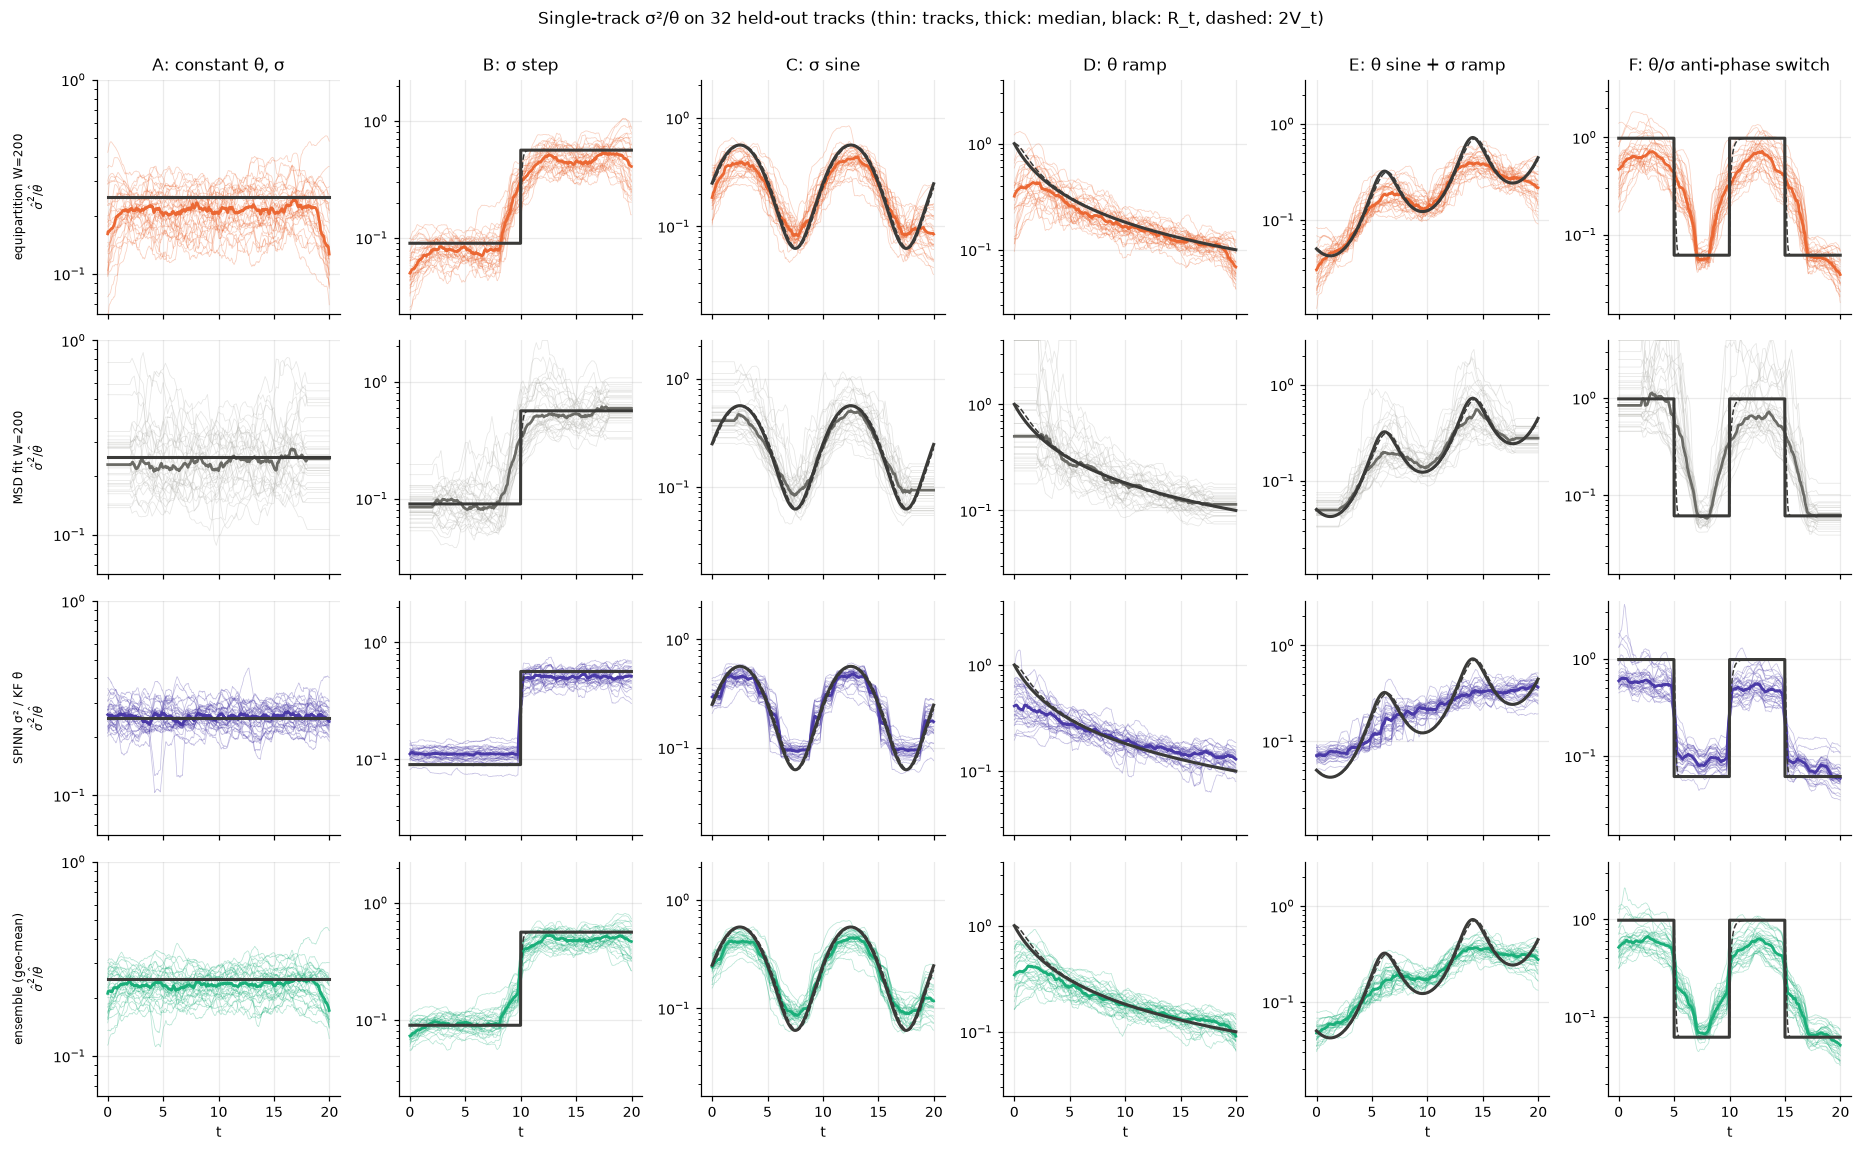

In [7]:
SHOW_R = [('均分 (W=200)', '#eb6834', 'equipartition W=200'),
          ('MSD 拟合 (W=200)', '#b0b0aa', 'MSD fit W=200'),
          ('SPINN σ² / KF θ', '#4a3aa7', 'SPINN σ² / KF θ'),
          ('集成', '#1baf7a', 'ensemble (geo-mean)')]
fig, axes = plt.subplots(len(SHOW_R), 6, figsize=(17, 2.6 * len(SHOW_R)), sharex=True)
for j, name in enumerate(names):
    R = TRUTH[name]['R']
    lo, hi = R.min() / 4, R.max() * 4
    for i, (m, col, lab) in enumerate(SHOW_R):
        ax = axes[i, j]
        est = np.clip(R_EST[name][m], lo, hi)
        ax.plot(t_grid, est.T, color=col, lw=0.5, alpha=0.3)
        ax.plot(t_grid, np.median(est, axis=0), color=col if col != '#b0b0aa' else '#6b6b66', lw=1.8)
        ax.plot(t_grid, TRUTH[name]['R_trans'], color=C_TRUE, lw=1, ls='--')
        ax.plot(t_grid, R, color=C_TRUE, lw=2)
        ax.set_yscale('log'); ax.set_ylim(lo, hi)
        if i == 0: ax.set_title(EN[name])
        if j == 0: ax.set_ylabel(f'{lab}\n' + r'$\hat\sigma^2/\hat\theta$', fontsize=8)
        if i == len(SHOW_R) - 1: ax.set_xlabel('t')
fig.suptitle('Single-track σ²/θ on 32 held-out tracks (thin: tracks, thick: median, black: R_t, dashed: 2V_t)', y=1.0)
fig.tight_layout(); plt.show()

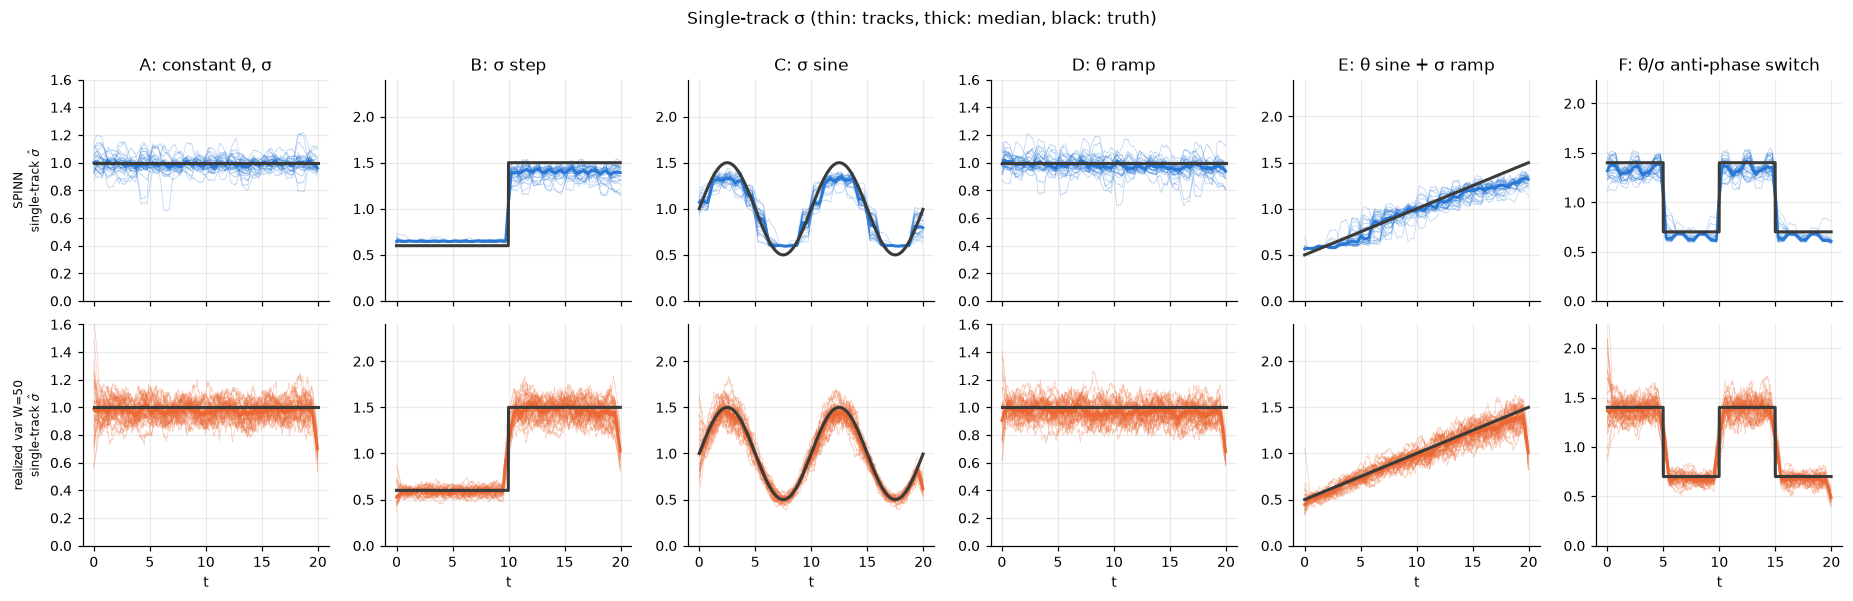

In [8]:
fig, axes = plt.subplots(2, 6, figsize=(17, 5.4), sharex=True)
for j, name in enumerate(names):
    sg = TRUTH[name]['sigma']
    for i, (m, col, lab) in enumerate([('SPINN', '#2a78d6', 'SPINN'), ('实现方差 (W=50)', '#eb6834', 'realized var W=50')]):
        ax = axes[i, j]
        ax.plot(t_grid, S_EST[name][m].T, color=col, lw=0.5, alpha=0.3)
        ax.plot(t_grid, np.median(S_EST[name][m], axis=0), color=col, lw=1.8)
        ax.plot(t_grid, sg, color=C_TRUE, lw=2)
        ax.set_ylim(0, 1.6 * sg.max())
        if i == 0: ax.set_title(EN[name])
        if j == 0: ax.set_ylabel(f'{lab}\n' + r'single-track $\hat\sigma$', fontsize=8)
        if i == 1: ax.set_xlabel('t')
fig.suptitle('Single-track σ (thin: tracks, thick: median, black: truth)', y=1.0)
fig.tight_layout(); plt.show()

## 6. 轨迹长度的影响

与 `SPINN_OU_theta_explore.ipynb` 相同，截断到前 $T'$ 帧与直接用长度为 $T'$ 的轨迹推断完全等价。比较 $T'\in\{300,500,1000\}$ 时的 $\sigma^2/\theta$ logMAE 与 $\sigma$ MRE（6 个情景平均）。不同长度评估的时间段不同，重点看同一长度下的相对排名。

In [9]:
len_rows = []
for Tp in [300, 500, 1000]:
    sl = slice(0, Tp)
    for name in names:
        X, s1 = DATA[name]['X'][:, sl], RES[name]['s1'][:, sl]
        est = {'均分 (W=200)': 2 * rollvar(X, 200), 'SPINN σ² / KF θ': spinn_kf_R(X, s1)}
        est['集成'] = np.sqrt(est['均分 (W=200)'] * est['SPINN σ² / KF θ'])
        est['MSD 拟合 (W=200)'] = msd_fit(X)[0]
        for m, v in est.items():
            len_rows.append({'帧数': Tp, '量': 'σ²/θ logMAE', '方法': m, '值': score_R(v, name, sl)['logMAE']})
        sig = {'SPINN': np.sqrt(_roll(s1.mean(axis=2, keepdims=True), 25)[..., 0] / DT),
               '实现方差 (W=50)': np.sqrt(_roll((np.diff(X, axis=1, append=X[:, -1:]) ** 2).mean(axis=2, keepdims=True), 50)[..., 0] / DT)}
        for m, v in sig.items():
            len_rows.append({'帧数': Tp, '量': 'σ MRE', '方法': m, '值': score_sigma(v, name, sl)['MRE']})
len_df = pd.DataFrame(len_rows).pivot_table(index='帧数', columns=['量', '方法'], values='值', aggfunc='mean')
len_df.style.format('{:.3f}')

## 7. 结论与建议

以下数字来自 32 条独立测试轨迹（每个情景，$\mu_i$ 各不相同），SPINN 模型为 `SPINN_OU_demo.ipynb` 中 `QUICK = True`、`SEED = 0` 训练得到。

**1. 改成直接估计 $\sigma^2/\theta$ 和 $\sigma$ 是可行的，而且比估计 $\theta$ 更稳。**

- $\sigma$：单轨迹相对误差约 7%，趋势相关 0.95–0.99。
- $\sigma^2/\theta$：最好的方法单轨迹对数误差约 0.27（典型误差约 25%–30%），B、C、D、F 中的趋势相关为 0.93–0.99。

**2. 各方法表现（σ²/θ 的 logMAE，6 个情景平均）**

| 方法 | logMAE | 说明 |
|---|---|---|
| 均分 $W=200$ | 0.347 | 最简单，趋势都能看出来，E 中最好；整体略偏低（有限窗口内去掉局部均值会低估方差，$\theta$ 越小越明显），F 的阶跃处被窗口抹平 |
| MSD 拟合 $W=200$ | 0.375 | 粒子追踪的经典方法，与均分相当或略差 |
| AR(1) $W=200$ | 0.397 | 滑动窗口 OU 回归，比均分差 |
| RV σ² / KF θ（无 SPINN） | 0.275 | 与下一行几乎相同 |
| **SPINN σ² / KF θ** | **0.268** | 平均最好，B/C/D/F 的趋势相关最高；E 中较差，因为卡尔曼把正弦的 $\theta$ 抹平了 |
| 集成（几何平均） | 0.275 | 最均衡，没有一个情景特别差 |

**3. SPINN 的作用要实事求是地看**

- 估计 $\sigma$ 时，SPINN 与最简单的实现方差（50 帧窗口内 $\sum\Delta X^2$）平均误差相同（都是 0.069）。SPINN 在 A、D、F 略好，在 C、E 略差。
- 估计 $\sigma^2/\theta$ 时，把 SPINN 的单步方差换成实现方差，误差只从 0.268 升到 0.275。**性能提升主要来自卡尔曼的时变 $\theta$ 模型，而不是 SPINN。**
- 对这个目标，SPINN 在理想 OU 模拟数据上带来的额外收益很小。它的价值可能体现在模拟中没有包含的情况：定位噪声、非高斯的跳跃、偏离 OU 的漂移等。这些需要在更贴近实验的模拟中再验证。

**4. 对实验的建议**

- $\sigma_t$：SPINN 或实现方差都可以，两者可以互相验证。
- $\sigma^2_t/\theta_t$：推荐 `SPINN σ² / KF θ`（或不用网络的 `RV σ² / KF θ`），同时画出均分 $W=200$ 作为模型无关的对照。两者一致时结论可靠；如果均分显示出振荡而卡尔曼版本是平的（像 E），以均分为准。
- 均分方法要求参数变化比松弛时间 $1/\theta$ 慢。在 F 这种突变处，任何窗口方法都会滞后约半个窗口。

**5. 值得继续尝试的方向**

- **定位噪声**：真实实验中定位误差 $\epsilon$ 会让 $\mathrm{MSD}(\tau)$ 多出 $2\epsilon^2$，使单步方差和 $\sigma$ 偏大。可以在模拟中加入定位噪声（`cfg.noise_adding`），检验 SPINN 是否比实现方差更稳健。
- **直接对 $R_t$ 做状态空间建模**：把 $\log R_t$ 与 $\log\sigma_t$ 作为隐状态，写出 OU 的精确转移似然，做粒子滤波或变分推断，同时估计两者并给出不确定度。
- **让 SPINN 直接学习局部方差**：例如增加一个预测局部位置方差的输出头，需要修改网络并重新训练。